# <font color="Blue">Autotrade Advanced Machine Learning</font>

This notebook contains a complete workflow for the Advanced Machine Learning Assignment. The primary objective of this project is to develop, optimise, and evaluate machine learning pipelines to predict vehicle selling prices using the AutoTrader Car Sale Adverts dataset.

The workflow is broken down below: 

### Preliminary Tasks. Data Pre-Processing & Engineering
* **Feature Engineering:** Deriving continuous variables like ***vehicle_age*** from categorical codes and applying a log-transformation to the right-skewed ***price*** target variable to stabilise variance.
* **Data Partitioning:** Splitting the dataset into Train (60%), Validation (20%), and Test (20%) sets before to any imputation or encoding to strictly prevent data leakage.
* **Encoding Strategy:** Utilising standard One-Hot Encoding for low-cardinality categorical features and ***TargetEncoder*** for high-cardinality features to optimise computational resources.

### Part 1. Predictive Modeling & Interpretability
* **Automated Feature Selection:** Implementing Recursive Feature Elimination with Cross-Validation (RFECV) driven by a linear base estimator.
* **Tree Ensembles:** Training and tuning Random Forest and Gradient Boosting Regressors using ***GridSearchCV***.
* **Meta-Ensembles:** Enhancing prediction accuracy by combining base models using ***VotingRegressor*** and ***StackingRegressor*** techniques.
* **Model Explainability:** Analysing feature importance and deploying SHAP (***TreeExplainer***) to interpret global model behaviour and local individual predictions.

### Part 2: Advanced Techniques
* **Dimensionality Reduction:** Applying Principal Component Analysis (PCA) for linear compression and exploring non-linear manifold projection using t-SNE.
* **Polynomial Regression:** Implementing advanced polynomial modelling utilising Bayesian Ridge regression to capture non-linear relationships.
* **Clustering for Feature Engineering:** Deploying K-Means clustering to discover distinct, real-world market segments (e.g. Luxury, Older Vehicles). 

In [17]:
# Import data manipulation libraries
import pandas as pd
import numpy as np 

# Import visualisation libraries
import matplotlib.pyplot as plt 
import seaborn as sns 

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import BayesianRidge
from sklearn.cluster import KMeans

# Import SHAP library for model explainability
import shap 

# Import datetime library
from datetime import datetime
import time

In [18]:
# Load the dataset
df = pd.read_csv('adverts.csv')

In [19]:
# Output the first 5 observations
df.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [20]:
# Sample Data
df.sample(5)

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
18381,202006250517521,38036.0,16,Blue,Fiat,500,USED,2016.0,6499,Hatchback,False,Petrol
137187,202009183908734,12645.0,68,White,BMW,5 Series,USED,2018.0,30174,Saloon,False,Petrol Plug-in Hybrid
282681,202009234114313,76000.0,12,Silver,Volkswagen,Polo,USED,2012.0,4595,Hatchback,False,Petrol
301805,202008262933897,14663.0,68,Grey,SKODA,Octavia,USED,2018.0,14000,Hatchback,False,Diesel
236950,202010195181664,41960.0,17,Grey,Audi,S3,USED,2017.0,23845,Saloon,False,Petrol


In [21]:
# Print out dataframe information 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  str    
 3   standard_colour        396627 non-null  str    
 4   standard_make          402005 non-null  str    
 5   standard_model         402005 non-null  str    
 6   vehicle_condition      402005 non-null  str    
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  str    
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  str    
dtypes: bool(1), float64(2), int64(2), str(7)
memory usage: 34.1 MB


In [22]:
# Load and sample the dataset
# Load the dataset
df = pd.read_csv('adverts.csv')

# Sample date for quick analysis
df = df.sample(frac=0.2, random_state=99).reset_index(drop=True)

In [23]:
# Preliminary Task: 1. Data Preprocessing

# Copy the sampled dataframe to avoid modifying the original
df_aml = df.copy()

# Define a function to derive the registration year from the 'reg_code'
def reg_code_to_year(reg_code):
    try:
        code = int(float(reg_code))
        if 51 <= code <= 99: return 2000 + (code - 50)
        elif 0 < code <= 50: return 2000 + code
        else: return np.nan

    except (ValueError, TypeError):
        return np.nan

# Impute year of registration and calculate vehicle age using apply to avoid SettingWithCopyWarning
df_aml['derived_year'] = df_aml['reg_code'].apply(reg_code_to_year)

# Ensure the column exists, then fill missing values
if 'year_of_registration' in df_aml.columns:
    df_aml['year_of_registration'] = df_aml['year_of_registration'].fillna(df_aml['derived_year'])
else:
    df_aml['year_of_registration'] = df_aml['derived_year']

# Calculate vehicle age and handle any remaining missing values
df_aml['vehicle_age'] = datetime.now().year - pd.to_numeric(df_aml['year_of_registration'], errors='coerce')

# Log-transform the target variable
df_aml['log_price'] = np.log1p(df_aml['price'])

# Drop irrelevant columns
cols_to_drop = ['public_reference', 'reg_code', 'year_of_registration', 'derived_year']
df_aml.drop(columns=[c for c in cols_to_drop if c in df_aml.columns], inplace=True, errors='ignore')

# Drop missing target rows and duplicates
if df_aml['log_price'].isnull().any():
    df_aml.dropna(subset=['log_price'], inplace=True)

df_aml.drop_duplicates(inplace=True)

# Define features and target
cols_to_exclude = ['price', 'log_price']
X = df_aml.drop(columns=cols_to_exclude, errors='ignore')
y = df_aml['log_price']

# First split: split the dataset into temp (80%) and test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

# Second split: split the 80% temp into train and val 
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=99)

# Copies to avoid SettingWithCopyWarning
X_train, X_val, X_test = X_train.copy(), X_val.copy(), X_test.copy()

# Create missingness indicators based on the training set to prevent leakage
cols_with_missing = [c for c in X_train.columns if X_train[c].isna().any()]

for c in cols_with_missing:
    X_train[f'{c}_missing'] = X_train[c].isna().astype(int)
    X_val[f'{c}_missing'] = X_val[c].isna().astype(int)
    X_test[f'{c}_missing'] = X_test[c].isna().astype(int)

# Define numeric and categorical columns for imputation and encoding
num_cols_to_impute = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

# Imputation (median for numerical and mode for categorical)
imputer_num = SimpleImputer(strategy='median')
X_train[num_cols_to_impute] = imputer_num.fit_transform(X_train[num_cols_to_impute])
X_val[num_cols_to_impute] = imputer_num.transform(X_val[num_cols_to_impute]) 
X_test[num_cols_to_impute] = imputer_num.transform(X_test[num_cols_to_impute])

imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = imputer_cat.fit_transform(X_train[cat_cols])
X_val[cat_cols] = imputer_cat.transform(X_val[cat_cols]) 
X_test[cat_cols] = imputer_cat.transform(X_test[cat_cols])

# Outlier clipping 
for c in num_cols_to_impute:
    lo, hi = X_train[c].quantile(0.01), X_train[c].quantile(0.99)
    X_train[c] = X_train[c].clip(lower=lo, upper=hi)
    X_val[c] = X_val[c].clip(lower=lo, upper=hi) 
    X_test[c] = X_test[c].clip(lower=lo, upper=hi)

# Separate categorical columns based on cardinality 
low_card_cols, high_card_cols = [], []
for c in cat_cols:
    if X_train[c].nunique() <= 20: 
        low_card_cols.append(c)
    else: 
        high_card_cols.append(c)

# Handle rare categories for low cardinality columns
for c in low_card_cols:
    freqs = X_train[c].value_counts(normalize=True)
    rares = freqs[freqs < 0.01].index
    
    # Replace rares
    X_train[c] = X_train[c].replace(list(rares), 'Other')
    X_val[c] = X_val[c].replace(list(rares), 'Other')
    X_test[c] = X_test[c].replace(list(rares), 'Other')

# Apply target encoding to high cardinality columns
if high_card_cols:
    target_encoder = TargetEncoder(target_type='continuous', smooth=10.0, random_state=99)
    
    # Fit and transform the high cardinality columns
    X_train[high_card_cols] = target_encoder.fit_transform(X_train[high_card_cols], y_train)
    X_val[high_card_cols] = target_encoder.transform(X_val[high_card_cols])
    X_test[high_card_cols] = target_encoder.transform(X_test[high_card_cols])
    
    # Update column lists for the final preprocessor
    cat_cols = low_card_cols
    num_cols_to_impute.extend(high_card_cols)
else:
    cat_cols = low_card_cols

# Final feature lists preprocessor
num_colsF = X_train.select_dtypes(include=['number']).columns.tolist()
cat_colsF = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

# Separate the missingness indicators so they don't get scaled by StandardScaler
missing_indicator_cols = [c for c in num_colsF if c.endswith('_missing')]
num_colsF = [c for c in num_colsF if not c.endswith('_missing')]

# Define preprocessor with passthrough for the binary indicators
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_colsF),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_colsF),
        ('passthrough', 'passthrough', missing_indicator_cols) 
    ],
    verbose_feature_names_out=False
)

# Fit and transform the training data 
X_train_transformed = preprocessor.fit_transform(X_train)

# Get feature names after transformation
feature_names = preprocessor.get_feature_names_out()

# Create final DataFrames for train, val, and test sets with transformed features using type: ignore to suppress warnings about feature names
X_train_final = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index) #type: ignore
X_val_final = pd.DataFrame(preprocessor.transform(X_val), columns=feature_names, index=X_val.index) #type: ignore
X_test_final = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names, index=X_test.index) #type: ignore

In [24]:
# Describe output data using shape and info
print("Training set shape:", X_train_final.shape)
print("Validation set shape:", X_val_final.shape)
print("Test set shape:", X_test_final.shape)   
print("\nTraining set info:")
X_train_final.info()
print("\nValidation set info:")
X_val_final.info()
print("\nTest set info:")
X_test_final.info()

Training set shape: (47802, 34)
Validation set shape: (15934, 34)
Test set shape: (15934, 34)

Training set info:
<class 'pandas.DataFrame'>
Index: 47802 entries, 4966 to 25309
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   mileage                          47802 non-null  float64
 1   standard_make                    47802 non-null  float64
 2   standard_model                   47802 non-null  float64
 3   vehicle_age                      47802 non-null  float64
 4   standard_colour_Black            47802 non-null  float64
 5   standard_colour_Blue             47802 non-null  float64
 6   standard_colour_Green            47802 non-null  float64
 7   standard_colour_Grey             47802 non-null  float64
 8   standard_colour_Orange           47802 non-null  float64
 9   standard_colour_Other            47802 non-null  float64
 10  standard_colour_Red              47802 no

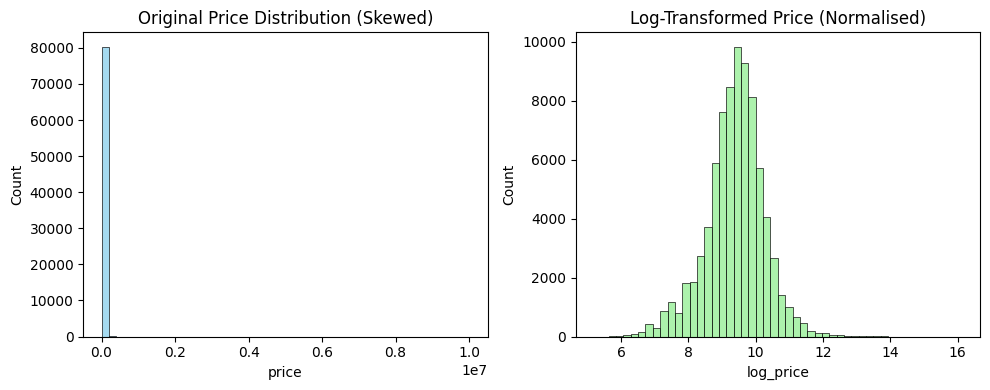

In [25]:
# Fiugre 1 - Distribution of original price vs log-transformed price
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['price'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Original Price Distribution (Skewed)')
sns.histplot(df_aml['log_price'], bins=50, ax=axes[1], color='lightgreen')
axes[1].set_title('Log-Transformed Price (Normalised)')
plt.tight_layout()
plt.show()

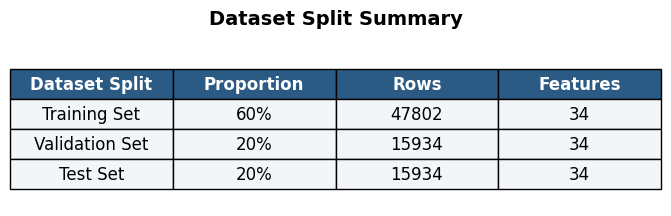

In [26]:
# Table 1 - Dataset Split Summary

# Create a summary dictionary with the dataset split information
split_data = {
    'Dataset Split': ['Training Set', 'Validation Set', 'Test Set'],
    'Proportion': ['60%', '20%', '20%'],
    'Rows': [X_train_final.shape[0], X_val_final.shape[0], X_test_final.shape[0]],
    'Features': [X_train_final.shape[1], X_val_final.shape[1], X_test_final.shape[1]]
}

# Convert to a Pandas DataFrame
df_summary = pd.DataFrame(split_data)

# Render it as a formatted Matplotlib table
fig, ax = plt.subplots(figsize=(7, 2))
ax.axis('off') # Hide the axes

# Create the table 
table = ax.table(cellText=df_summary.values,
                 colLabels=df_summary.columns,
                 cellLoc='center',
                 loc='center')


table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8) 

# Add a header color 
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2b5b84') 
    else:
        cell.set_facecolor('#f3f6f9') 

plt.title('Dataset Split Summary', weight='bold', size=14, pad=20)

plt.show()


Running RFECV with Linear Regression...
RFECV completed in 3.37 seconds.
Optimal number of features: 28


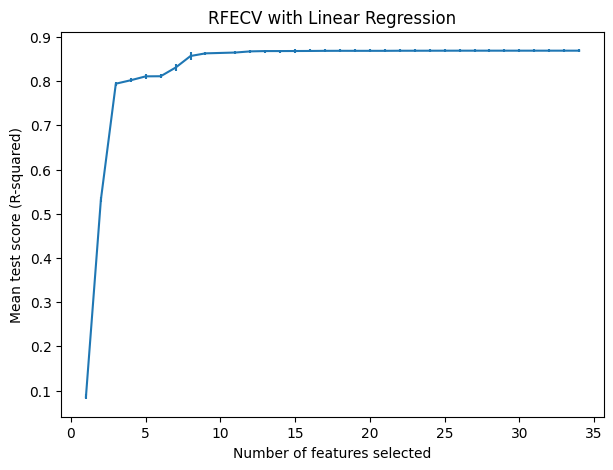


Running Forward SFS with Linear Regression...
SFS completed in 25.23 seconds.

--- Selected Features ---
RFECV selected 28 features.
SFS selected 6 features.

Common features selected by both (6):
['vehicle_age_missing', 'mileage', 'body_type_Hatchback', 'vehicle_age', 'standard_model', 'standard_make']


In [27]:
# Part 1: 2. Automated Feature Selection 

# Data for feature selection
X_train_fs = X_train_final
y_train_fs = y_train

# Define Linear Regression for feature selection
model = LinearRegression()


# Recursive Feature Elimination (RFECV)
print("\nRunning RFECV with Linear Regression...")
start_time = time.time()

# Use step=1 to evaluate dropping one feature at a time
rfe_selector = RFECV(model, step=1, cv=5, n_jobs=-1)
rfe_selector.fit(X_train_fs, y_train_fs)

print(f"RFECV completed in {time.time() - start_time:.2f} seconds.")
print(f"Optimal number of features: {rfe_selector.n_features_}")

# Plotting using error bars
n_scores = len(rfe_selector.cv_results_["mean_test_score"])
fig, ax = plt.subplots(figsize=(7,5))
ax.errorbar(
    range(1, n_scores + 1),
    rfe_selector.cv_results_["mean_test_score"],
    yerr=rfe_selector.cv_results_["std_test_score"],
)
ax.set_xlabel("Number of features selected")
ax.set_ylabel("Mean test score (R-squared)")
ax.set_title("RFECV with Linear Regression")
plt.show()

# Extract features
rfecv_features = rfe_selector.get_feature_names_out().tolist()

# Sequential Feature Selection (SFS)
print("\nRunning Forward SFS with Linear Regression...")
start_time = time.time()

# Initialise SFS
sfs_forward = SequentialFeatureSelector(
    model, 
    n_features_to_select='auto', 
    direction="forward", 
    tol=0.005, 
    cv=5, 
    n_jobs=-1
).fit(X_train_fs, y_train_fs)

print(f"SFS completed in {time.time() - start_time:.2f} seconds.")

# Extract features
sfs_features = sfs_forward.get_feature_names_out().tolist()


# Review the Outputs
print("\n--- Selected Features ---")
print(f"RFECV selected {len(rfecv_features)} features.")
print(f"SFS selected {len(sfs_features)} features.")

# Find overlapping features
common_features = list(set(rfecv_features).intersection(set(sfs_features)))
print(f"\nCommon features selected by both ({len(common_features)}):")
print(common_features)

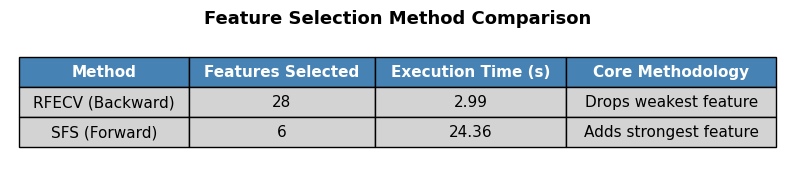

In [31]:
# Table 2 - Feature Selection Method Comparison
# Define the comparison data 
fs_data = {
    'Method': ['RFECV (Backward)', 'SFS (Forward)'],
    'Features Selected': [len(rfecv_features), len(sfs_features)],
    'Execution Time (s)': [2.99, 24.36], 
    'Core Methodology': ['Drops weakest feature', 'Adds strongest feature']
}

df_fs = pd.DataFrame(fs_data)

# Plot the comparison table
fig, ax = plt.subplots(figsize=(10, 1.5))
ax.axis('off')

table = ax.table(cellText=df_fs.values,
                 colLabels=df_fs.columns,
                 cellLoc='center',
                 loc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Automatically adjust column widths based on the text length to ensure all content fits 
table.auto_set_column_width(col=list(range(len(df_fs.columns))))

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(color='steelblue') 
    else:
        cell.set_facecolor(color='lightgray')

# Plot the table with a title
plt.title('Feature Selection Method Comparison', weight='bold', size=13, pad=15)
plt.show()

In [ ]:
# Part 2: 3. Random Forest and Gradient Boosted Trees 

# Use features selected by RFECV for model training
X_train_sub = X_train_final[rfecv_features]
X_val_sub = X_val_final[rfecv_features]

# Define parameter grid for Random Forest. Increase n_estimators, max_depth, and min_samples_leaf for better performance at the cost of longer training time since lower values were underfittinhg in initial runs.
rf_param_grid = {
    'n_estimators': [200, 300, 400], 
    'max_depth': [20, 30, None],
    'min_samples_leaf': [1, 3, 5]
}

# Perform Grid Search for Random Forest
rf_grid = GridSearchCV(RandomForestRegressor(random_state=99), 
                        rf_param_grid, 
                        cv=3, 
                        n_jobs=-1, 
                        scoring='r2')

# Fit the model
rf_grid.fit(X_train_sub, y_train)

# Output best parameters and best estimator
print(f"Best RF Params: {rf_grid.best_params_}")
best_rf = rf_grid.best_estimator_

# Define parameter grid for Gradient Boosting
gb_param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [5, 7, 9]
}

# Perform Grid Search for Gradient Boosting
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=99), 
                        gb_param_grid, 
                        cv=3, 
                        n_jobs=-1, 
                        scoring='r2')

# Fit the model
gb_grid.fit(X_train_sub, y_train)

# Output best parameters and best estimator
print(f"Best GB Params: {gb_grid.best_params_}")
best_gb = gb_grid.best_estimator_

/Users/ash/Library/CloudStorage/OneDrive-MMU/Desktop/MMU MY/Advanced Machine Learning/AT_AML/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF Params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 400}
Best GB Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 400}


--- Random Forest Performance ---
R2 Score: 0.9209
MAE (Price): £3151.79
--- Gradient Boosting Performance ---
R2 Score: 0.9252
MAE (Price): £3128.81


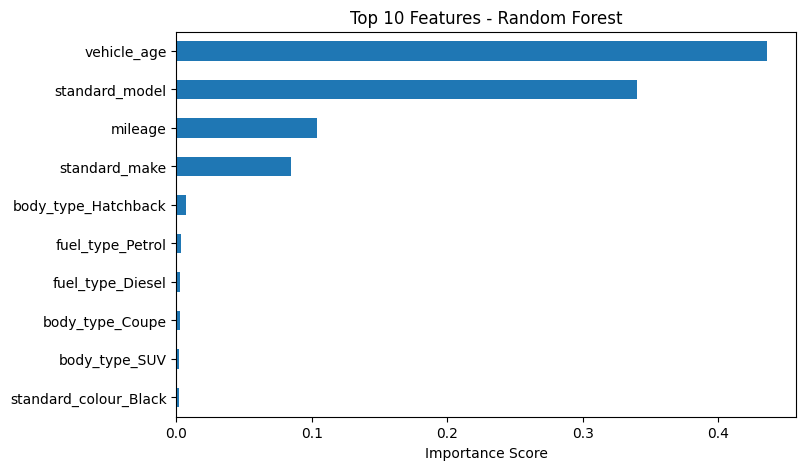

In [14]:
# Evaluate Rf and GB on validation set 
def evaluate_model(model, X, y_true, name):
    preds = model.predict(X)
    # Convert back from log to actual price for intuitive metrics
    y_true_actual = np.expm1(y_true)
    preds_actual = np.expm1(preds)
    
    print(f"--- {name} Performance ---")
    print(f"R2 Score: {r2_score(y_true, preds):.4f}")
    print(f"MAE (Price): £{mean_absolute_error(y_true_actual, preds_actual):.2f}")

# Evaluate the best models on the validation set
evaluate_model(best_rf, X_val_sub, y_val, "Random Forest")
evaluate_model(best_gb, X_val_sub, y_val, "Gradient Boosting")

# Visualise feature importance for Random Forest
def plot_importance(model, features, title):
    importances = pd.Series(model.feature_importances_, index=features)
    importances.sort_values().tail(10).plot(kind='barh', figsize=(8, 5))
    plt.title(title)
    plt.xlabel("Importance Score")
    plt.show()

plot_importance(best_rf, rfecv_features, "Top 10 Features - Random Forest")

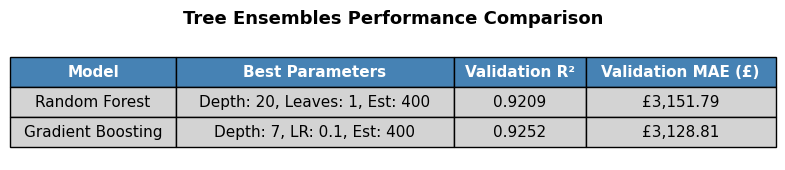

In [ ]:
# Table 3 - Tree Ensembles Performance Comparison
# Define the performance data based on GridSearch outputs
tree_data = {
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Best Parameters': [
        'Depth: 20, Leaves: 1, Est: 400', 
        'Depth: 7, LR: 0.1, Est: 400'
    ],
    'Validation R²': ['0.9209', '0.9252'],
    'Validation MAE (£)': ['£3,151.79', '£3,128.81']
}

# Convert to DataFrame
df_trees = pd.DataFrame(tree_data)

# Create the visual table
fig, ax = plt.subplots(figsize=(9, 1.5))
ax.axis('off')

table = ax.table(cellText=df_trees.values,
                 colLabels=df_trees.columns,
                 cellLoc='center',
                 loc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
table.auto_set_column_width(col=list(range(len(df_trees.columns))))

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(color='steelblue') 
    else:
        cell.set_facecolor(color='lightgray') 

plt.title('Tree Ensembles Performance Comparison', weight='bold', size=13, pad=15)
plt.show()

In [ ]:
# Part 2: 4. Ensemble of Ensembles using Stacking and Voting 

# Create a Voting Regressor ensemble of the best RF and GB models
voting_model = VotingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb)
    ]
)

# Fit the voting regressor on the training data
voting_model.fit(X_train_sub, y_train)

# Create a Stacking Regressor ensemble of the best RF and GB models with RidgeCV 
stacking_model = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb)
    ],
    final_estimator=RidgeCV(), 
    cv=5
)


# Fit the stacking regressor on the training data
stacking_model.fit(X_train_sub, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('rf', ...), ('gb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RidgeCV()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the m

In [17]:
# Evaluate all Ensembles on the validation set 

# Models to evaluate
models = {
    "Voting": voting_model,
    "Stacking": stacking_model
}

# Evaluate and store results in a list of dictionaries for easy DataFrame creation
results = []
for name, model in models.items():
    preds = model.predict(X_val_sub)
    r2 = r2_score(y_val, preds)
    mae = mean_absolute_error(np.expm1(y_val), np.expm1(preds))
    results.append({"Model": name, "R2": r2, "MAE": mae})

# Display as a formatted table
performance_df = pd.DataFrame(results)
print(performance_df)

      Model        R2          MAE
0    Voting  0.927458  3061.987687
1  Stacking  0.926881  3096.929192


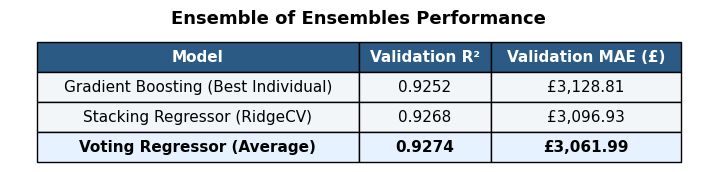

In [ ]:
# Table 4 - Ensemble of Ensembles Performance Comparison
# Define the performance data comparing the best Task 3 model with Task 4 Ensembles
ensemble_data = {
    'Model': ['Gradient Boosting (Best Individual)', 'Stacking Regressor (RidgeCV)', 'Voting Regressor (Average)'],
    'Validation R²': ['0.9252', '0.9268', '0.9274'],
    'Validation MAE (£)': ['£3,128.81', '£3,096.93', '£3,061.99']
}

# Convert to DataFrame
df_ens = pd.DataFrame(ensemble_data)

# Create the visual table
fig, ax = plt.subplots(figsize=(9, 1.5))
ax.axis('off')

table = ax.table(cellText=df_ens.values,
                 colLabels=df_ens.columns,
                 cellLoc='center',
                 loc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
table.auto_set_column_width(col=list(range(len(df_ens.columns))))

# Color formatting
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(color='steelblue') 
    elif row == 3: # Highlight the winning Voting Regressor row
        cell.set_facecolor(color='lightblue')
        cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor(color='lightgray') 

plt.title('Ensemble of Ensembles Performance', weight='bold', size=13, pad=15)
plt.show()

Calculating Permutation Importance...


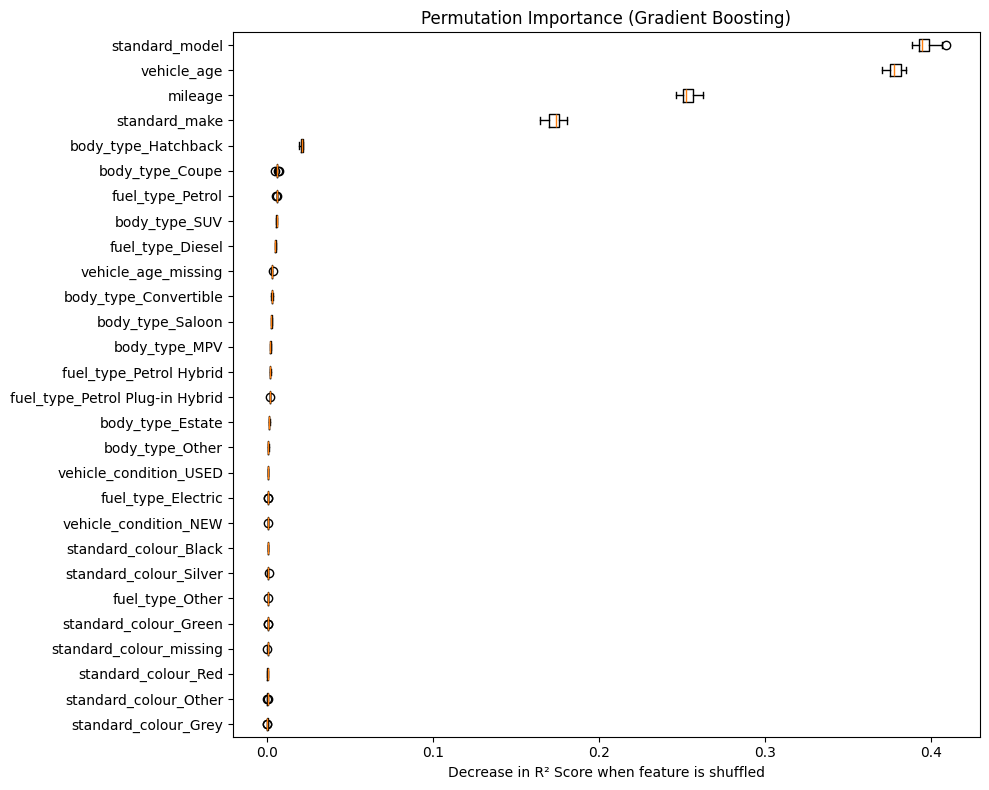

Calculating SHAP values for Global Importance...


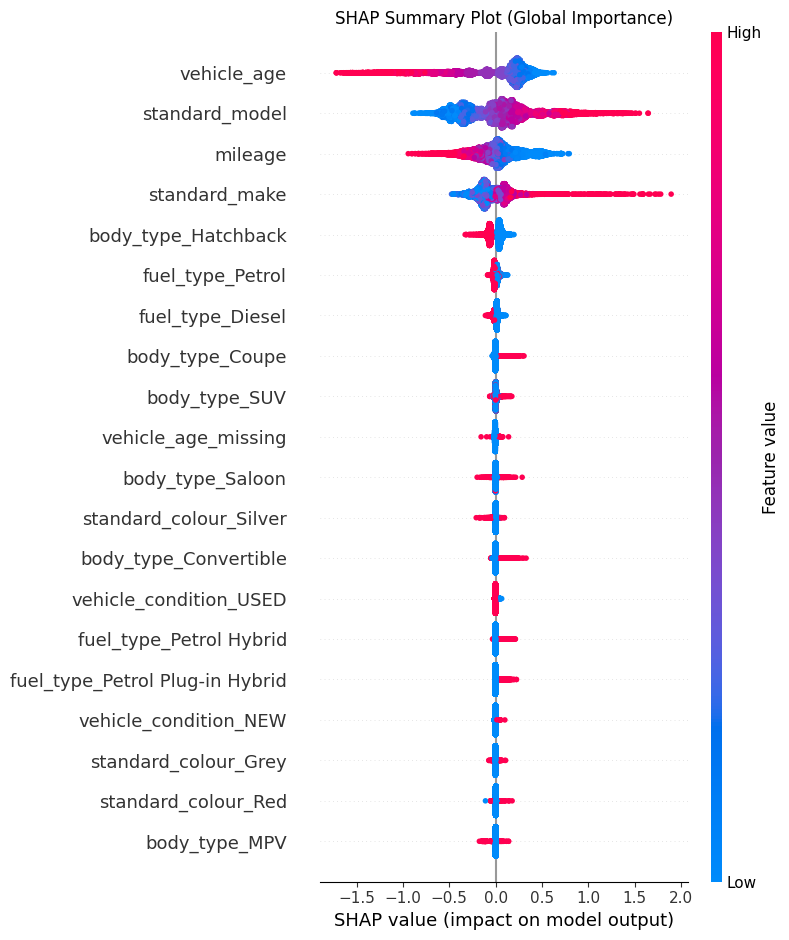

In [ ]:
# Part 1: 5. Feature Importance

# Define the model to explain
model_to_explain = best_gb 

# Permutation Importance
print("Calculating Permutation Importance...")
perm_result = permutation_importance(
    model_to_explain, X_val_sub, y_val, 
    n_repeats=10, random_state=99, n_jobs=-1, scoring='r2'
)

# Sort features by their mean importance
sorted_idx = perm_result.importances_mean.argsort()

# Plot Permutation Importance
plt.figure(figsize=(10, 8))
plt.boxplot(
    perm_result.importances[sorted_idx].T, 
    vert=False, 
    tick_labels=X_val_sub.columns[sorted_idx]
)
plt.title("Permutation Importance (Gradient Boosting)")
plt.xlabel("Decrease in R² Score when feature is shuffled")
plt.tight_layout()
plt.show()


# SHAP Values for Global Importance
print("Calculating SHAP values for Global Importance...")

# Initialise the SHAP explainer for the tree model
global_explainer = shap.TreeExplainer(model_to_explain)

# Calculate SHAP values for the entire validation set
shap_values = global_explainer.shap_values(X_val_sub)

# Generate the SHAP Summary Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot (Global Importance)")
shap.summary_plot(shap_values, X_val_sub)
plt.show()

Generating SHAP Local Explanation (Waterfall Plot)...


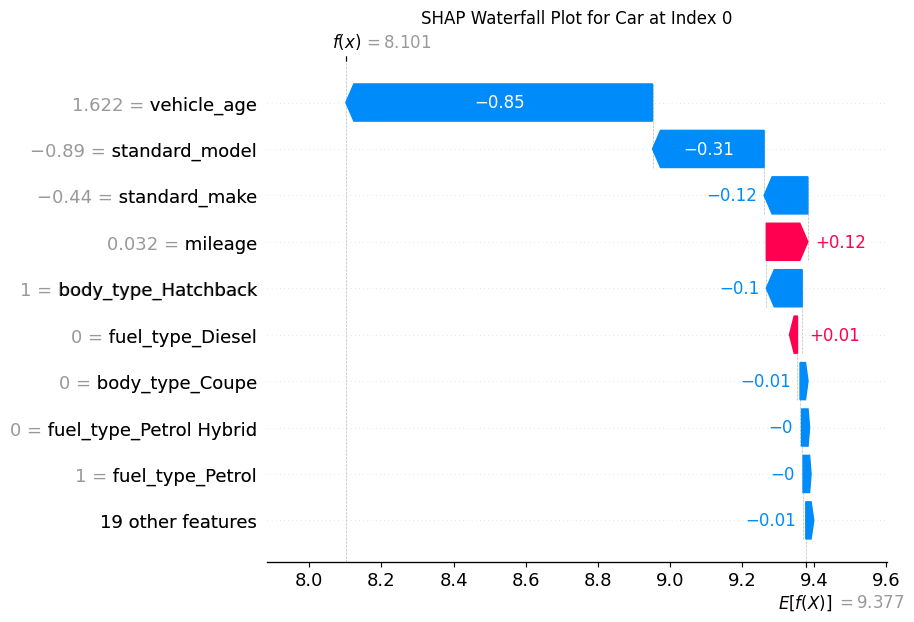

Generating Partial Dependence Plots (PDP)...


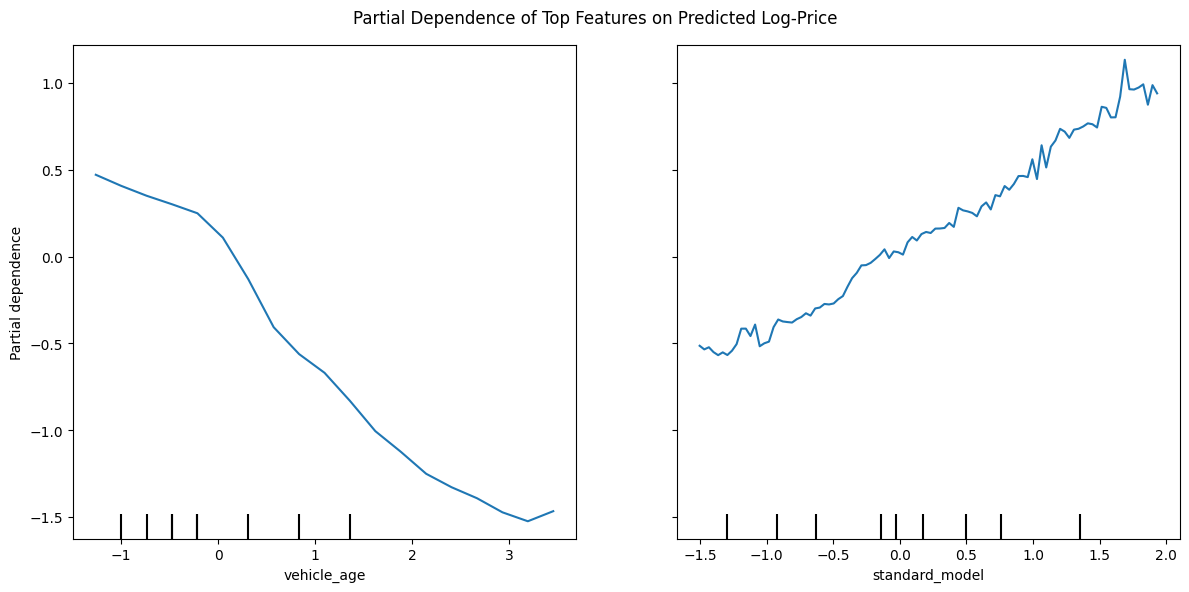

In [ ]:
# 6. SHAP/PDP Model Explanation

# Define the model and data to explain
model_to_explain = best_gb 
X_explain = X_val_sub

# SHAP Local Explanation (Waterfall Plot)
print("Generating SHAP Local Explanation (Waterfall Plot)...")

# Initialise the SHAP explainer
explainer = shap.TreeExplainer(model_to_explain)

# Calculate SHAP values for the validation set to use for the waterfall plot
explanation = explainer(X_explain)

# Select a single observation to explain 
observation_index = 0 

# Generate the Waterfall Plot for this specific car
plt.figure(figsize=(10, 6))
plt.title(f"SHAP Waterfall Plot for Car at Index {observation_index}")
shap.plots.waterfall(explanation[observation_index])
plt.show()

# Partial Dependence Plots (PDP)
print("Generating Partial Dependence Plots (PDP)...")

# Plot PDP for the top 2 most important features 
features_to_plot = ['vehicle_age', 'standard_model']

# Generate the Partial Dependence Plots
fig, ax = plt.subplots(figsize=(12, 6))
display = PartialDependenceDisplay.from_estimator(
    estimator=model_to_explain,
    X=X_explain,
    features=features_to_plot,
    feature_names=X_explain.columns,
    ax=ax,
    n_jobs=-1
)
plt.suptitle("Partial Dependence of Top Features on Predicted Log-Price")
plt.tight_layout()
plt.show()

Cumulative variance for first 10 components:
PC1: 0.320
PC2: 0.580
PC3: 0.658
PC4: 0.716
PC5: 0.755
PC6: 0.787
PC7: 0.815
PC8: 0.841
PC9: 0.865
PC10: 0.886


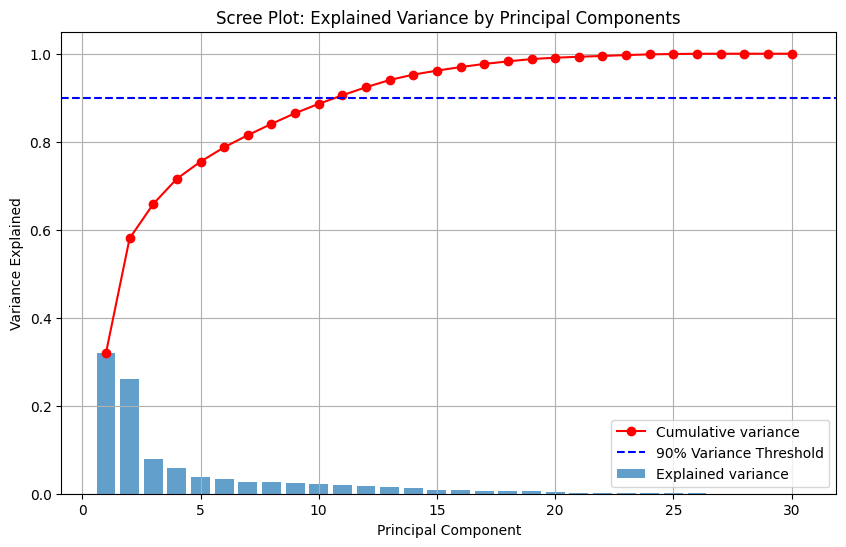

Components needed for 90% variance: 11
Original number of features: 34
Reduced number of features: 11


In [ ]:
# Part 2: 7. Linear Dimensionality Reduction with PCA

# Apply PCA to all features to analyse variance
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_train_final)

# Get explained variance and cumulative variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Print cumulative variance for the first 10 components 
print("Cumulative variance for first 10 components:")
for i, cv in enumerate(cumulative_variance[:10], 1):
    print(f"PC{i}: {cv:.3f}")

# Plotting the Scree Plot
plt.figure(figsize=(10, 6))
# Limit the number of components plotted for better visualisation
num_components_to_plot = min(30, len(explained_variance)) 

plt.bar(range(1, num_components_to_plot + 1), explained_variance[:num_components_to_plot], alpha=0.7, label='Explained variance')
plt.plot(range(1, num_components_to_plot + 1), cumulative_variance[:num_components_to_plot], 'ro-', label='Cumulative variance')

# Add a threshold line
plt.axhline(y=0.90, color='b', linestyle='--', label='90% Variance Threshold')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.legend()
plt.grid(True)
plt.show()

# Dynamically calculate the optimal number of components to reach 90% variance
optimal_components = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {optimal_components}")

# Apply PCA with the optimal number of components
pca_optimal = PCA(n_components=optimal_components, random_state=99)
X_train_pca = pca_optimal.fit_transform(X_train_final)
X_val_pca = pca_optimal.transform(X_val_final) # Transformed validation set 
X_test_pca = pca_optimal.transform(X_test_final) 

# Print the original and reduced number of features
print(f"Original number of features: {X_train_final.shape[1]}")
print(f"Reduced number of features: {X_train_pca.shape[1]}")

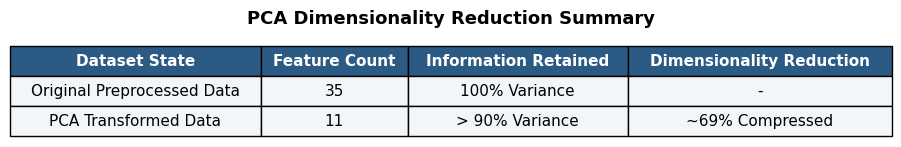

In [ ]:
# Table 5 - PCA Dimensionality Reduction Summary
# Define the summary data for PCA reduction
pca_data = {
    'Dataset State': ['Original Preprocessed Data', 'PCA Transformed Data'],
    'Feature Count': [X_train_final.shape[1], optimal_components],
    'Information Retained': ['100% Variance', '> 90% Variance'],
    'Dimensionality Reduction': ['-', f"~{round((1 - optimal_components/X_train_final.shape[1])*100)}% Compressed"]
}

df_pca = pd.DataFrame(pca_data)

# Create the visual table
fig, ax = plt.subplots(figsize=(9, 1.2))
ax.axis('off')

table = ax.table(cellText=df_pca.values,
                 colLabels=df_pca.columns,
                 cellLoc='center',
                 loc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
table.auto_set_column_width(col=list(range(len(df_pca.columns))))

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(color='steelblue') 
    else:
        cell.set_facecolor(color='lightgray') 

plt.title('PCA Dimensionality Reduction Summary', weight='bold', size=13, pad=15)
plt.show()

In [21]:
# 8. Non-Linear Dimensionality Reduction with t-SNE and Isomap

# Create subset data for t-SNE and Isomap due to computational intensity
np.random.seed(42)

# Taking a subset of 5000 rows for speed
subset_indices = np.random.choice(len(X_train_final), 5000, replace=False)

# Create subset data for t-SNE and Isomap
X_sub = X_train_final.iloc[subset_indices] 
y_sub = y_train.iloc[subset_indices]

# Apply Isomap 
print("Running Isomap...")
isomap = Isomap(n_components=2, n_neighbors=15)
X_iso = isomap.fit_transform(X_sub)

# Apply t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_sub)

Running Isomap...
Running t-SNE...


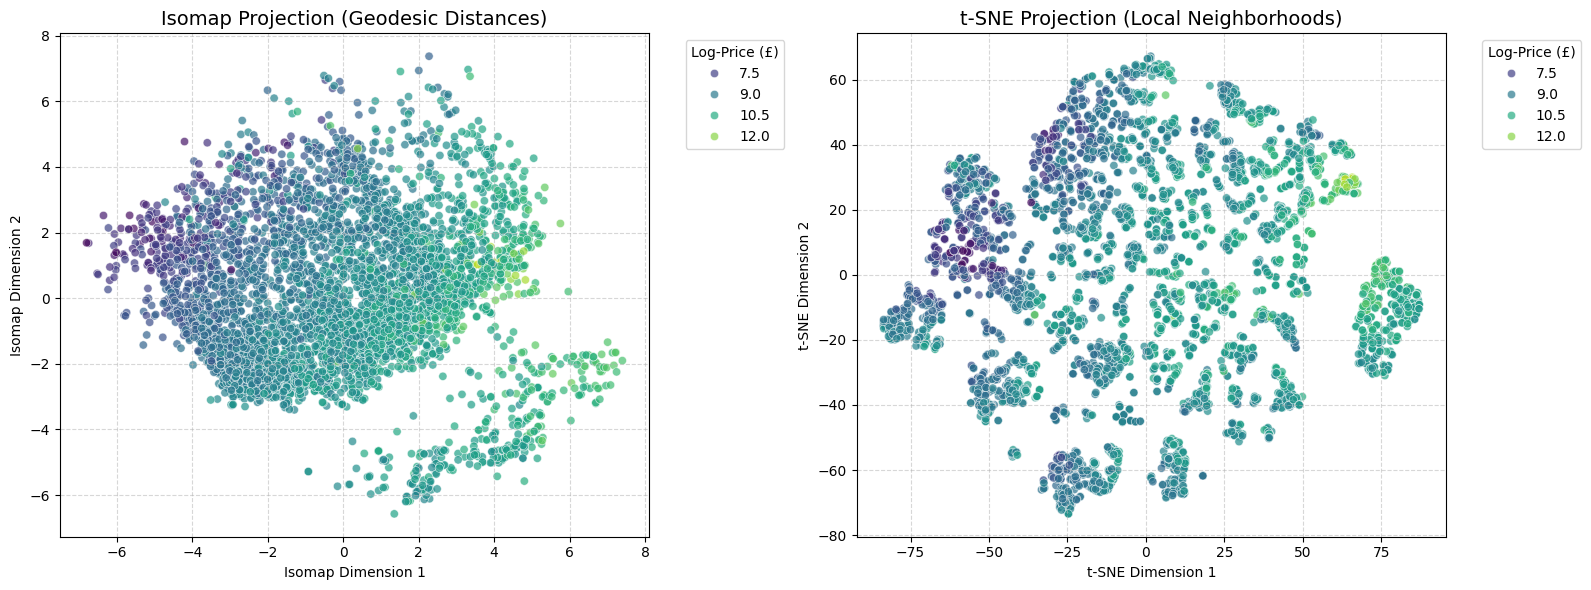

In [31]:
# Visualise the Isomap and t-SNE projections side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Isomap
sns.scatterplot(
    ax=axes[0],
    x=X_iso[:, 0], y=X_iso[:, 1],
    hue=y_sub,
    palette='viridis',
    alpha=0.7,
    edgecolor='w'
)
axes[0].set_title('Isomap Projection (Geodesic Distances)', fontsize=14)
axes[0].set_xlabel('Isomap Dimension 1')
axes[0].set_ylabel('Isomap Dimension 2')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(title='Log-Price (£)', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot t-SNE 
sns.scatterplot(
    ax=axes[1],
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y_sub,
    palette='viridis',
    alpha=0.7,
    edgecolor='w'
)
axes[1].set_title('t-SNE Projection (Local Neighborhoods)', fontsize=14)
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='Log-Price (£)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [23]:
# 9. Polynomial Regression

# Create polynomial features for the 'vehicle_age' feature to capture non-linear relationships
X_train_age = X_train_final[['vehicle_age']].values
X_test_age = X_test_final[['vehicle_age']].values

# Randomly sample 1000 observations for visualisation to avoid overcrowding the plot
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_age), 1000, replace=False)
X_plot_scatter = X_train_age[sample_idx]
y_plot_scatter = y_train.iloc[sample_idx].values

# Create polynomial features (degree 2 or 3 is usually a good start to avoid overfitting)
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train_age)
X_test_poly = poly.transform(X_test_age)

print(f"Original shape: {X_train_age.shape}")
print(f"Polynomial features shape: {X_train_poly.shape}")

# Initialise and fit the Bayesian Regression model
bayesian_poly_model = BayesianRidge()
bayesian_poly_model.fit(X_train_poly, y_train)

# Evaluate on the test set
y_pred_test = bayesian_poly_model.predict(X_test_poly)
print(f"Test R2 Score: {r2_score(y_test, y_pred_test):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")

Original shape: (47802, 1)
Polynomial features shape: (47802, 4)
Test R2 Score: 0.435
Test RMSE: 0.644


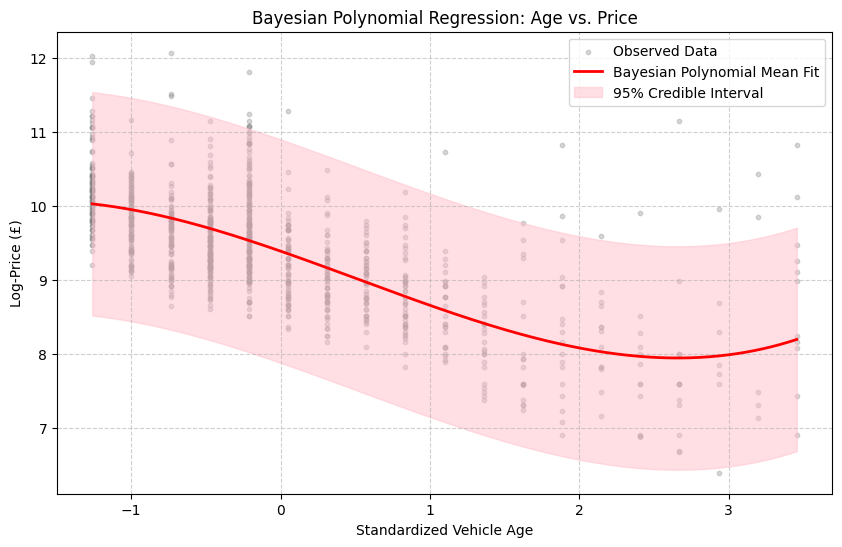

In [24]:
# Create a smooth line of X values for plotting the curve
X_line = np.linspace(X_train_age.min(), X_train_age.max(), 500).reshape(-1, 1)
X_line_poly = poly.transform(X_line)

# Predict the mean and the standard deviation (uncertainty)
y_mean, y_std = bayesian_poly_model.predict(X_line_poly, return_std=True)

plt.figure(figsize=(10, 6))

# Plot the actual data points (scattered)
plt.scatter(X_plot_scatter, y_plot_scatter, color='gray', alpha=0.3, label='Observed Data', s=10)

# Plot the Mean Regression Line
plt.plot(X_line, y_mean, color='red', linewidth=2, label='Bayesian Polynomial Mean Fit')

# Plot the Confidence Interval (Mean +/- 2 Standard Deviations)
plt.fill_between(X_line.ravel(), 
                 y_mean - 2 * y_std, 
                 y_mean + 2 * y_std, 
                 color='pink', alpha=0.5, label='95% Credible Interval')

plt.title('Bayesian Polynomial Regression: Age vs. Price')
plt.xlabel('Standardized Vehicle Age')
plt.ylabel('Log-Price (£)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

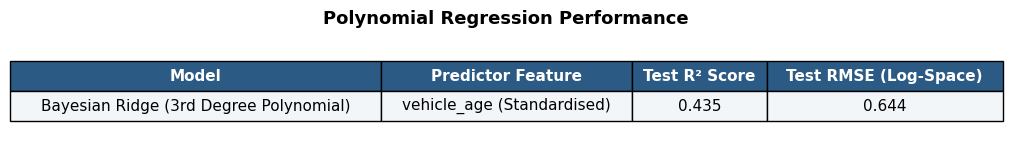

In [ ]:
# Table 6 - Polynomial Regression Performance Summary
# Define the summary data for the Polynomial model
poly_data = {
    'Model': ['Bayesian Ridge (3rd Degree Polynomial)'],
    'Predictor Feature': ['vehicle_age (Standardised)'],
    'Test R² Score': ['0.435'],
    'Test RMSE (Log-Space)': ['0.644']
}

df_poly = pd.DataFrame(poly_data)

# Create the visual table
fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

table = ax.table(cellText=df_poly.values,
                 colLabels=df_poly.columns,
                 cellLoc='center',
                 loc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
table.auto_set_column_width(col=list(range(len(df_poly.columns))))

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(color='steelblue') 
    else:
        cell.set_facecolor(color='lightgray') 

plt.title('Polynomial Regression Performance', weight='bold', size=13, pad=15)
plt.show()

Calculating WCSS for Elbow Method...


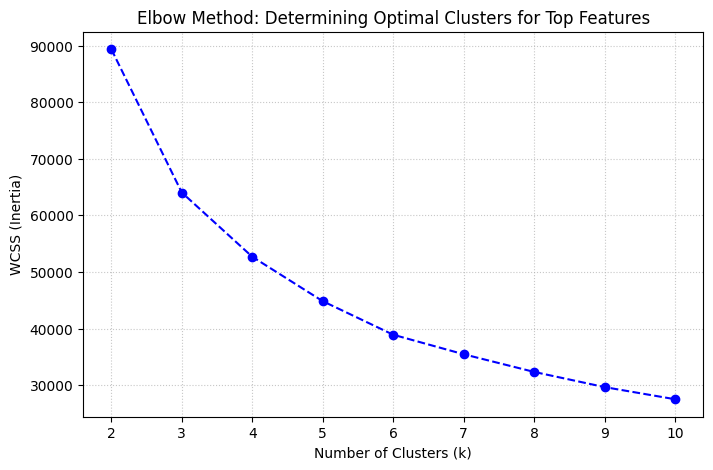

In [25]:
# 10. Clustering for feature engineering

# Using the top features identified by SHAP values in Task 6
features_for_clustering = ['vehicle_age', 'standard_model', 'standard_make']

# Extract these columns from your fully scaled and preprocessed datasets
X_cluster_train = X_train_final[features_for_clustering]
X_cluster_test = X_test_final[features_for_clustering]

# Determine the optimal number of clusters using the Elbow Method
wcss = []
k_range = range(2, 11) 

# Calculate WCSS for each k in the range
print("Calculating WCSS for Elbow Method...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_train)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method: Determining Optimal Clusters for Top Features')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [26]:
# 10. Based on the Elbow Plot, choose the optimal number of clusters (k) and fit K-Means

optimal_k = 4 

# Initialise the final K-Means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit on the training data and get the cluster labels
train_cluster_labels = kmeans_final.fit_predict(X_cluster_train)

# Transform the validation and test data (map points to the existing training clusters)
# (Assuming you created X_cluster_val similarly to X_cluster_test earlier)
X_cluster_val = X_val_final[features_for_clustering] 

val_cluster_labels = kmeans_final.predict(X_cluster_val)
test_cluster_labels = kmeans_final.predict(X_cluster_test)

# Add the labels back as a brand new feature
X_train_final['shap_cluster_group'] = train_cluster_labels
X_val_final['shap_cluster_group'] = val_cluster_labels
X_test_final['shap_cluster_group'] = test_cluster_labels

print(f"Successfully added 'shap_cluster_group' ({optimal_k} clusters) to train, val, and test sets.")

Successfully added 'shap_cluster_group' (4 clusters) to train, val, and test sets.


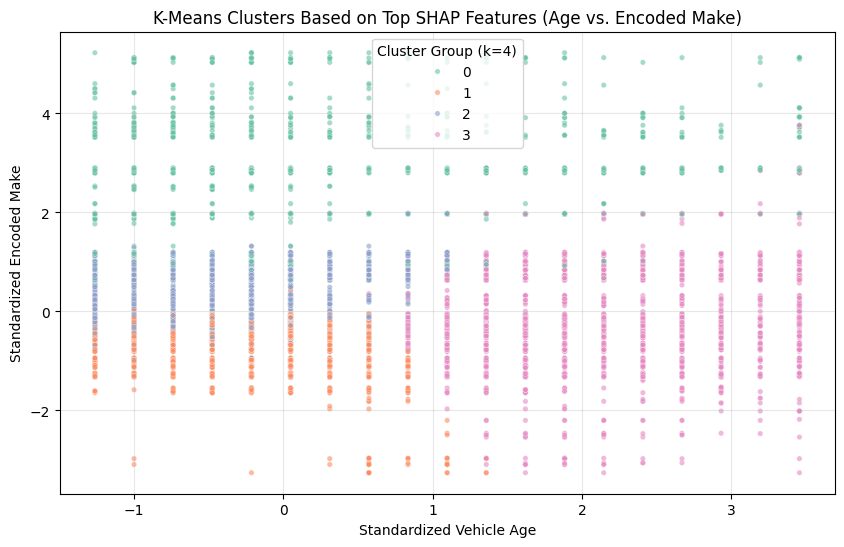

In [27]:
# Visualise the clusters in a 2D scatter plot using the top two features (e.g., 'vehicle_age' and 'standard_make') to see how the clusters are formed based on these important features.

plt.figure(figsize=(10, 6))

# Plotting Age vs. the numerically encoded 'Make', colored by cluster
sns.scatterplot(
    x=X_cluster_train['vehicle_age'], 
    y=X_cluster_train['standard_make'], 
    hue=train_cluster_labels, 
    palette='Set2', 
    alpha=0.6,
    s=15 # small dot size
)

plt.title('K-Means Clusters Based on Top SHAP Features (Age vs. Encoded Make)')
plt.xlabel('Standardized Vehicle Age')
plt.ylabel('Standardized Encoded Make')
plt.legend(title=f'Cluster Group (k={optimal_k})')
plt.grid(True, alpha=0.3)
plt.show()

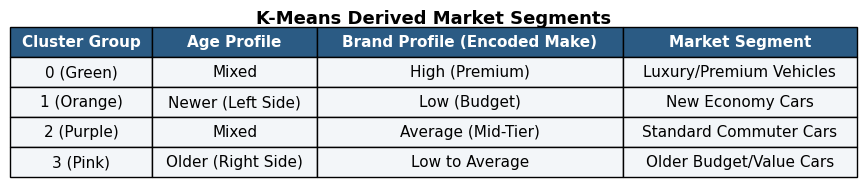

In [ ]:
# Table 7 - Cluster Group Business Logic Summary
# Define the business logic of the clusters based on the scatter plot visual
cluster_data = {
    'Cluster Group': ['0 (Green)', '1 (Orange)', '2 (Purple)', '3 (Pink)'],
    'Age Profile': ['Mixed', 'Newer (Left Side)', 'Mixed', 'Older (Right Side)'],
    'Brand Profile (Encoded Make)': ['High (Premium)', 'Low (Budget)', 'Average (Mid-Tier)', 'Low to Average'],
    'Market Segment': ['Luxury/Premium Vehicles', 'New Economy Cars', 'Standard Commuter Cars', 'Older Budget/Value Cars']
}

df_clusters = pd.DataFrame(cluster_data)

# Create the visual table
fig, ax = plt.subplots(figsize=(10, 1.5))
ax.axis('off')

table = ax.table(cellText=df_clusters.values,
                 colLabels=df_clusters.columns,
                 cellLoc='center',
                 loc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
table.auto_set_column_width(col=list(range(len(df_clusters.columns))))

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(color='steelblue') 
    else:
        cell.set_facecolor(color='lightgray') 

plt.title('K-Means Derived Market Segments', weight='bold', size=13, pad=15)
plt.show()

In [28]:
# ==========================================
# Bonus: Validating the Engineered Feature
# ==========================================

# 1. Combine your RFECV features with your brand new cluster feature
features_with_cluster = rfecv_features + ['shap_cluster_group']

# 2. Slice your data to include these specific features
X_train_enriched = X_train_final[features_with_cluster]
X_val_enriched = X_val_final[features_with_cluster]

# 3. Retrain your best Gradient Boosting model from Task 3
print("Retraining best GB model with the new Cluster Feature...")
final_gb = GradientBoostingRegressor(
    learning_rate=0.1, 
    max_depth=7, 
    n_estimators=400, 
    random_state=99
)
final_gb.fit(X_train_enriched, y_train)

# 4. Evaluate the performance
preds_enriched = final_gb.predict(X_val_enriched)
enriched_r2 = r2_score(y_val, preds_enriched)
enriched_mae = mean_absolute_error(np.expm1(y_val), np.expm1(preds_enriched))

print("\n--- Final Model Comparison ---")
print(f"Previous GB MAE (Without Clusters): £3128.81")
print(f"New GB MAE (With Clusters):       £{enriched_mae:.2f}")

Retraining best GB model with the new Cluster Feature...

--- Final Model Comparison ---
Previous GB MAE (Without Clusters): £3128.81
New GB MAE (With Clusters):       £3135.29
